# One-sample means and the $t$-distribution

---

#### Summary videos

- [Central Limit Theorem for the sample mean](https://youtu.be/lsCc_pS3O28?si=FWDUsNBDqXvjQcyr) (4 minutes)
- [$t$-distribution](https://youtu.be/uVEj2uBJfq0?si=0fqbV_7N6zP8kzzh) (7 minutes)
- [Inference for a mean](https://youtu.be/RYVIGj1l4xs?si=63dD9FuEEOX8iFsS) (10 minutes)

#### Walkthrough videos

- [The central limit theorem for sample means](https://drive.google.com/file/d/1mNzLmYR7cClhtgW3Q4lfdXiQ7xuXsHsE/view?usp=sharing) (7 minutes)
- [The $t$-distribution](https://drive.google.com/file/d/1WZ0LvdZ3Up5y6d5mobyN17p7RTPahpln/view?usp=sharing) (12 minutes)
- [One-sample $t$-confidence intervals](https://drive.google.com/file/d/1_hRgIKNXxdFaiOG9fm6Sy3u5SzN03lIu/view?usp=sharing) (15 minutes)
- [One-sample $t$-tests](https://drive.google.com/file/d/13tfYon5Z2er-Xzis-qk_ZTfV9VeNM4Oq/view?usp=sharing) (14 minutes)

---

In Chapters 5 and 6, we saw how — under certain conditions expressed by the Central Limit Theorem — a normal distribution could be used to model the distribution of sample proportions.

A similar concept is true for sample means, but we'll see that something called the $t$-distribution typically offers a better approximation of the distribution of sample means than a normal distribution.

## Central Limit Theorem for sample means (page 251)

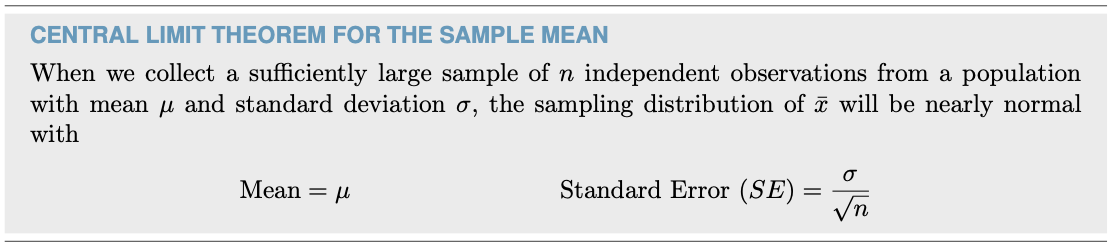

There is an extra condition on normality that is also important to check in this case — if the sample size is *small*, we want the samples to be nearly normal themselves. This condition is vague and difficult to assess, but some guidelines are listed below (from page 251 of the textbook).

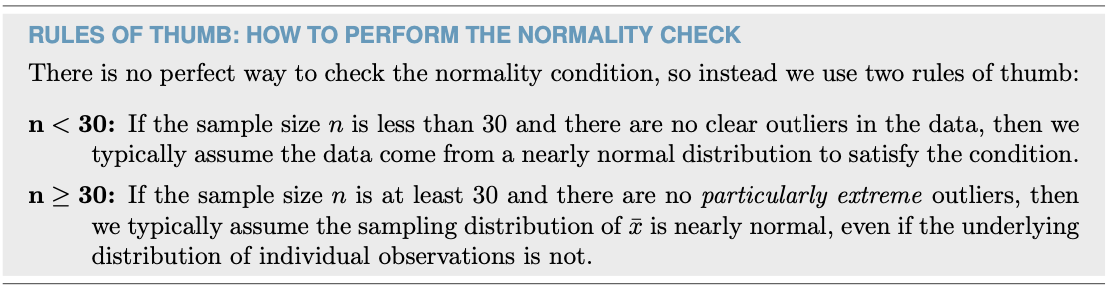

## One-sample $t$-confidence intervals

A simple random sample of 19 dolphins was conducted in order to evaluate the average mercury content in the dolphins' muscle tissue. A table summarizing the results (from page 255) is below.

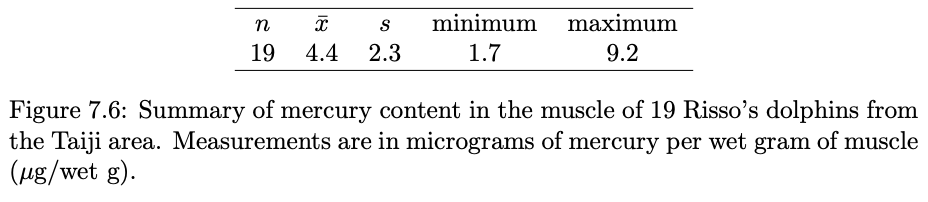

### Exercise

Are the independence and normality conditions met?

### Exercise

- Use [GeoGebra](https://www.geogebra.org/classic#probability) to visualize a normal distribution with mean and standard deviation given by the Central Limit Theorem.
  - Note that the true population standard deviation, $\sigma$, is not known. Use the sample standard deviation, $s$, to approximate it.
- Compare this normal distribution to the **$t$-distribution** (also called the **Student distribution**) with degrees of freedom equal to $19 - 1 = 18$.
  - Pay particular attention to the difference in tail areas — which distribution has heavier tails?

### Question

How does the shape $t$-distribution change as the degrees of freedom increase?

#### Answer


As the degrees of freedom increase, the $t$-distribution approaches the standard normal distribution.

### Why use a $t$-distribution?

> - While similar to the normal distribution, the $t$-distribution is designed to be a more accurate model for distributions of sample means in account of the use of $s$ to approximate $\sigma$.
> - If the populations standard deviation ($\sigma$) is known or if the $t$-distribution's degrees of freedom are at least 30, a normal distribution can be used instead of a $t$-distribution.

### Example 7.9 (page 256)

Let's compute and interpret a 95% confidence interval for the average mercury content in Risso's dolphins.

- The margin of error will be based on the $t$-distribution instead of the normal distribution.
  - Using a $t$-distribution with 18 degrees of freedom, find a value $t^*$ such that 95% of the $t$-distribution lies between $-t^*$ and $t^*$.
  - Compute margin of error as $t^* \times SE = t^* \times \frac{s}{\sqrt{n}}$.
- As before, we find the confidence interval as $(\text{point estimate}) \pm (\text{margin or error})$.
  - Using $\bar{x}$ as the point estimate, determine the confidence interval.
- Interpret what this confidence interval tells us about the average mercury content of this population of dolphins.

In [ ]:
# Check your result with this function
# Single mean confidence interval, using t-distribution

import numpy as np
import scipy.stats as stats

def mean_confidence_interval(mean, standard_deviation, sample_size, confidence_level):
  t_star = stats.t.ppf(1 - (1 - confidence_level) / 2, df = sample_size - 1)

  standard_error = standard_deviation/np.sqrt(sample_size)

  lower = mean - t_star * standard_error
  upper = mean + t_star * standard_error

  print(f"{confidence_level * 100}% confidence interval: ({lower}, {upper})")

In [ ]:
mean_confidence_interval(4.4, 2.3, 19, 0.95)

In [ ]:
# .ppf (Probability Point Function) can find the t_star value.
# The first input should be the area under the curve to the left of t_star.
# The second input is the degrees of freedom for the t-distribution.

stats.t.ppf(0.975, 18)

Below is a summary of this process from page 257 of the textbook.

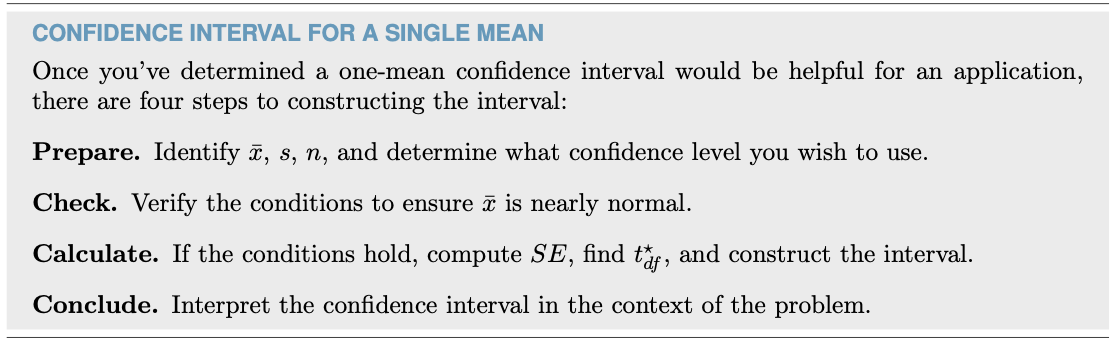

## One-sample $t$-tests

The Cherry Blossom Race is a 10-mile race held in Washington D.C. each spring. In 2006, the average time to complete the race was 93.29 minutes. Using a random sample of 100 participants from 2017, we'd like to determine with racers are getting faster or slower over time, on average.

Below is a histogram summarizing the completion times for the sample of 100 racers from 2017 (page 258).

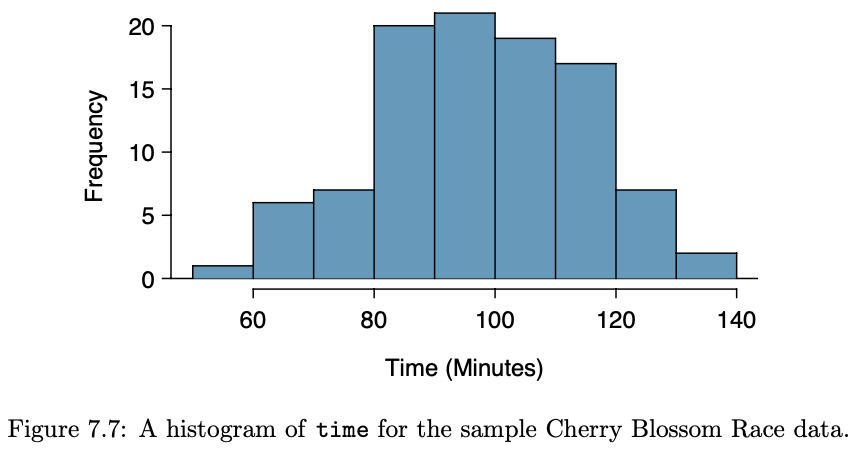

### Exercise

- Construct appropriate null and alternative hypothesis for this situation.
- Are the independence and normality conditions satisfied?

### Example 7.19 (page 258)

In 2017, 100 racers were sampled and it was found that there average finishing time as 97.32 minutes with a standard deviation of 16.98 minutes.

Use a $t$-distribution and significance level $\alpha = 0.05$ to complete a hypothesis test and draw an appropriate conclusion.

> Note that finding a T-score is analagous to finding a Z-score, but is based on a $t$-distribution instead of a normal distribution. However, finding a T-score is actually *necessary* (whereas there were technological workarounds for finding Z-scores).

In [ ]:
# Check your result with the function below

def mean_t_test(mean, standard_deviation, sample_size, null_value):
  standard_error  = standard_deviation / np.sqrt(sample_size)

  t_score = (mean - null_value)/standard_error

  p_value = (1 - stats.t.cdf(abs(t_score), df = sample_size - 1)) * 2

  print(f"T-score: {t_score}")
  print(f"p-value: {p_value}")

In [ ]:
mean_t_test(97.32, 16.98, 100, 93.29)

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.